# **11. ECT — EpiClimate-Transformer**

Extensión del Transformer baseline con:
- **Dual encoder** (EpiEncoder + ClimateEncoder) con ramas independientes
- **Cross-Attention** entre series epidemiológicas y covariables climáticas
- **Adaptive lag module** (lags 2–8 semanas aprendidos, no fijos)
- **Predicciones por departamento** con intervalos de confianza
- **Métricas por departamento** (RMSE, MAE, R²)
- Mismo esquema de validación temporal nested CV que el baseline DCRNN

## **11.1. Librerías**

In [1]:
import os
import copy
import random
import optuna

import numpy as np
import pandas as pd

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

import math
import sys
import time
import scipy.stats as st

import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, pacf

/home/moon/miniconda3/envs/deeplearning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **11.2. Configuración Reproducibilidad**

In [2]:
SEEDS = [42, 123, 2024]

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("DEVICE:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Python:", sys.version)
print("Torch:",  torch.__version__)
print("Numpy:",  np.__version__)
print("Pandas:", pd.__version__)

DEVICE: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU
Python: 3.11.15 (main, Mar 11 2026, 17:20:07) [GCC 14.3.0]
Torch: 2.12.0.dev20260407+cu128
Numpy: 2.4.3
Pandas: 3.0.2


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    torch.use_deterministic_algorithms(True)
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Seed fijada: {seed}")


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


g = torch.Generator()

## **11.3. Carga de Datos & Preprocesamiento**

### **11.3.1. Carga de Datos**

In [4]:
# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv("/home/moon/DEEP/PF/CODE/PF/df_full.csv")

df["fecha_inicio"] = pd.to_datetime(df["fecha_inicio"])

df = df.sort_values(
    ["departamento", "fecha_inicio"]
).reset_index(drop=True)

print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head()

Filas: 21664 | Columnas: 52


,departamento,fecha_inicio,ano,semana,casos,casos_mujeres,casos_hombres,casos_rural,casos_urbano,n_0_4,...,precip_lag_20,temp_c,temp_lag_1,temp_lag_2,temp_lag_3,temp_lag_4,temp_lag_8,temp_lag_12,temp_lag_20,dpto_ccdgo
0,Amazonas,2012-01-02,2012,1,0.0,0,0,0,0,0,...,39.108242,24.848668,24.890654,24.334752,24.545618,25.345678,25.278160,25.874930,24.364443,91
1,Amazonas,2012-01-09,2012,2,0.0,0,0,0,0,0,...,62.830250,24.729721,24.848668,24.890654,24.334752,24.545618,25.084141,25.495665,24.971798,91
2,Amazonas,2012-01-16,2012,3,0.0,0,0,0,0,0,...,42.988018,24.638674,24.729721,24.848668,24.890654,24.334752,25.751070,25.760539,25.304947,91
3,Amazonas,2012-01-23,2012,4,0.0,0,0,0,0,0,...,56.572467,25.164008,24.638674,24.729721,24.848668,24.890654,25.284157,25.842089,25.166142,91
4,Amazonas,2012-01-30,2012,5,0.0,0,0,0,0,0,...,74.893047,24.604644,25.164008,24.638674,24.729721,24.848668,25.345678,25.278160,25.312395,91


### **11.3.2. Feature Engineering**

El ECT mantiene las mismas features que el baseline, pero las separa en dos grupos:
- **EPIFEATURES**: serie de incidencia (lags epidemiológicos + variables socioeconómicas)
- **CLIMFEATURES**: covariables climáticas (temperatura, humedad, precipitación)

In [ ]:
df["semana"] = df["semana"].astype(int)
df["ano"]    = df["fecha_inicio"].dt.year

weeks_per_year = df.groupby("ano")["semana"].transform("max")
df["week_norm"] = df["semana"] / weeks_per_year
df["week_sin"]  = np.sin(2 * np.pi * df["week_norm"])
df["week_cos"]  = np.cos(2 * np.pi * df["week_norm"])

# Rama epidemiológica
EPIFEATURES = [
    "inc_lag_1",  "inc_lag_2",  "inc_lag_3",  "inc_lag_4",
    "inc_lag_8",  "inc_lag_12", "inc_lag_20",
    "poblacion",
    "prop_rural",
    "week_sin",
    "week_cos"
]

# Rama climática
CLIMFEATURES = [
    "temp_lag_1",    "temp_lag_2",    "temp_lag_4",
    "temp_lag_8",    "temp_lag_12",   "temp_lag_20",

    "humedad_lag_1", "humedad_lag_2", "humedad_lag_4",
    "humedad_lag_8", "humedad_lag_12","humedad_lag_20",

    "precip_lag_1",  "precip_lag_2",  "precip_lag_4",
    "precip_lag_8",  "precip_lag_12", "precip_lag_20",
]

# Lista unificada (para crear ventanas de forma consistente)
FEATURES = EPIFEATURES + CLIMFEATURES

df["incidencia_log"] = np.log1p(df["incidencia"])
TARGET = "incidencia_log"

N_EPI  = len(EPIFEATURES)
N_CLIM = len(CLIMFEATURES)

print(f"EpiFeatures : {N_EPI}")
print(f"ClimFeatures: {N_CLIM}")
print(f"Total       : {len(FEATURES)} | Target: {TARGET}")

EpiFeatures : 11
ClimFeatures: 18
Total       : 29 | Target: incidencia_log


### **11.3.3. Índices de Departamentos**

In [ ]:
departments = sorted(df["departamento"].unique())
dept_to_idx = {d: i for i, d in enumerate(departments)}
idx_to_dept = {i: d for d, i in dept_to_idx.items()}
NUM_NODES   = len(departments)

print(f"NUM_NODES: {NUM_NODES}")

NUM_NODES: 32


## **11.4. Esquema Validación Temporal**

In [ ]:

def create_outer_folds(df, date_col="fecha_inicio"):
    folds       = []
    outer_years = [2022, 2023, 2024]
    for test_year in outer_years:
        train_df = df[df[date_col].dt.year <  test_year].copy()
        test_df  = df[df[date_col].dt.year == test_year].copy()
        folds.append({
            "test_year": test_year,
            "train_df":  train_df,
            "test_df":   test_df
        })
    return folds

def create_inner_folds(train_df, val_years=[2019, 2020, 2021]):
    inner_folds = []
    for val_year in val_years:
        inner_train = train_df[
            train_df["fecha_inicio"].dt.year < val_year
        ].copy()
        inner_val = train_df[
            train_df["fecha_inicio"].dt.year == val_year
        ].copy()
        inner_folds.append({
            "val_year":    val_year,
            "inner_train": inner_train,
            "inner_val":   inner_val
        })
    return inner_folds


outer_folds = create_outer_folds(df)

## **11.5. Ventanas de Tiempo & Escalamiento**

In [ ]:

def create_windows(df, features, target, window_size=12, horizon=4):
    pivot_features = []
    for feat in features:
        pivot = df.pivot_table(
            index="fecha_inicio",
            columns="departamento",
            values=feat
        ).sort_index()
        pivot_features.append(pivot.values)

    X_all = np.stack(pivot_features, axis=-1)   # (T, nodes, n_features)

    target_pivot = df.pivot_table(
        index="fecha_inicio",
        columns="departamento",
        values=target
    ).sort_index()

    y_all  = target_pivot.values
    dates  = target_pivot.index.values

    X, y, base_dates = [], [], []
    total_steps = len(dates)

    for i in range(total_steps - window_size - horizon + 1):
        X.append(X_all[i : i + window_size])
        y.append(y_all[i + window_size : i + window_size + horizon])
        base_dates.append(dates[i + window_size - 1])

    return (
        np.array(X, dtype=np.float32),
        np.array(y, dtype=np.float32),
        np.array(base_dates)
    )


def scale_data(X_train, X_val):
    scaler       = RobustScaler()
    _, _, _, n_f = X_train.shape
    X_train_2d   = X_train.reshape(-1, n_f)
    scaler.fit(X_train_2d)
    X_train_sc   = scaler.transform(X_train_2d).reshape(X_train.shape)
    X_val_sc     = scaler.transform(X_val.reshape(-1, n_f)).reshape(X_val.shape)
    return X_train_sc, X_val_sc, scaler

## **11.6. Dataset & Utilidades de Entrenamiento**

In [ ]:

class ECTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class EarlyStopping:
    def __init__(self, patience=20):
        self.patience  = patience
        self.best_loss = np.inf
        self.counter   = 0
        self.stop      = False

    def step(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

def train_one_epoch(model, dataloader, criterion, optimizer, device, n_epi, n_clim):
    model.train()
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        pred, _ = model(X_batch, n_epi, n_clim)   
        loss = criterion(pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)


def validate_one_epoch(model, dataloader, criterion, device, n_epi, n_clim):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            pred, _ = model(X_batch, n_epi, n_clim)   
            loss = criterion(pred, y_batch)
            total_loss += loss.item()
    return total_loss / len(dataloader)

## **11.7. Arquitectura ECT — EpiClimate-Transformer**

### Innovaciones sobre el Transformer baseline:
1. **EpiEncoder** — Transformer encoder sobre los lags de incidencia + variables socioeconómicas.
2. **ClimateEncoder** — Transformer encoder independiente sobre covariables climáticas (temp, humedad, precipitación).
3. **AdaptiveLagModule** — aprende, por departamento, la ventana de lag relevante dentro del rango 2–8 semanas mediante atención aprendida sobre la dimensión temporal.
4. **CrossModalAttention** — módulo Multi-Head Cross-Attention donde la serie epidemiológica (Query) atiende a la representación climática (Key/Value), aprendiendo cuándo y cuánto pesa el clima sobre la epidemia.
5. **Fusion + Output head** — proyección final con dropout hacia el horizonte H=4 para cada nodo (departamento).

In [ ]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=256, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))   

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

In [ ]:
class AdaptiveLagModule(nn.Module):


    def __init__(self, d_model, max_lag=8):
        super().__init__()
        self.max_lag   = max_lag
        self.attn_proj = nn.Linear(d_model, 1)   

    def forward(self, x):
        B, T, N, D = x.shape

        x_lag = x[:, -self.max_lag:, :, :]      
        L = x_lag.shape[1]

        scores = self.attn_proj(x_lag).squeeze(-1).permute(0, 2, 1)  
        weights = F.softmax(scores, dim=-1)                           

        x_perm = x_lag.permute(0, 2, 1, 3)       
        context = torch.einsum("bnl,bnld->bnd", weights, x_perm)  
        return context, weights

In [ ]:
class CrossModalAttention(nn.Module):

    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model debe ser divisible por n_heads"
        self.mha  = nn.MultiheadAttention(
            embed_dim   = d_model,
            num_heads   = n_heads,
            dropout     = dropout,
            batch_first = True
        )
        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, epi_ctx, clim_ctx):
        attn_out, attn_weights = self.mha(
            query = epi_ctx,
            key   = clim_ctx,
            value = clim_ctx
        )
        fused = self.norm(epi_ctx + self.dropout(attn_out))
        return fused, attn_weights

In [ ]:
class ModalEncoder(nn.Module):

    def __init__(self, in_features, d_model, n_heads, n_layers,
                 dim_feedforward, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(in_features, d_model)
        self.pos_enc    = PositionalEncoding(d_model, dropout=dropout)

        encoder_layer   = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = n_heads,
            dim_feedforward = dim_feedforward,
            dropout         = dropout,
            batch_first     = True,
            norm_first      = True     
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers = n_layers,
            enable_nested_tensor=False 
        )

    def forward(self, x):
        x = self.input_proj(x)   
        x = self.pos_enc(x)
        x = self.encoder(x)      
        return x

In [ ]:
class EpiClimateTransformer(nn.Module):

    def __init__(
        self,
        num_nodes,
        n_epi,
        n_clim,
        d_model       = 64,
        n_heads       = 4,
        n_layers      = 2,
        dim_ff        = 128,
        horizon       = 4,
        max_lag       = 8,
        dropout       = 0.1
    ):
        super().__init__()
        self.num_nodes = num_nodes
        self.horizon   = horizon
        self.d_model   = d_model

        self.epi_encoder  = ModalEncoder(
            in_features     = n_epi,
            d_model         = d_model,
            n_heads         = n_heads,
            n_layers        = n_layers,
            dim_feedforward = dim_ff,
            dropout         = dropout
        )
        self.clim_encoder = ModalEncoder(
            in_features     = n_clim,
            d_model         = d_model,
            n_heads         = n_heads,
            n_layers        = n_layers,
            dim_feedforward = dim_ff,
            dropout         = dropout
        )

        self.lag_epi  = AdaptiveLagModule(d_model, max_lag=max_lag)
        self.lag_clim = AdaptiveLagModule(d_model, max_lag=max_lag)

        self.cross_attn = CrossModalAttention(d_model, n_heads, dropout)


        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(d_model, horizon)

    def forward(self, x, n_epi, n_clim):

        B, T, N, _ = x.shape

        X_epi  = x[:, :, :, :n_epi]              
        X_clim = x[:, :, :, n_epi:n_epi+n_clim]  


        X_epi_flat  = X_epi.permute(0, 2, 1, 3).reshape(B * N, T, n_epi)
        epi_enc     = self.epi_encoder(X_epi_flat)          
        epi_enc     = epi_enc.reshape(B, N, T, self.d_model).permute(0, 2, 1, 3)
                                                             

        X_clim_flat = X_clim.permute(0, 2, 1, 3).reshape(B * N, T, n_clim)
        clim_enc    = self.clim_encoder(X_clim_flat)        
        clim_enc    = clim_enc.reshape(B, N, T, self.d_model).permute(0, 2, 1, 3)
                                                             

        epi_ctx,  _           = self.lag_epi(epi_enc)       
        clim_ctx, lag_weights = self.lag_clim(clim_enc)     

        fused, attn_cross = self.cross_attn(epi_ctx, clim_ctx) 

        out = self.fc(self.dropout(fused))  
        out = out.permute(0, 2, 1)          

        return out, attn_cross

## **11.8. Optimización de Hiperparámetros (Optuna)**

Se mantienen los hiperparámetros del baseline y se añaden los específicos del ECT:
- `d_model`: dimensión interna del Transformer
- `n_heads`: cabezas de atención
- `n_layers`: capas por encoder
- `dim_ff`: dimensión feedforward
- `max_lag`: ventana máxima del AdaptiveLagModule

In [ ]:
ALL_OPTUNA_TRIALS  = []
ALL_OPTUNA_FOLDS   = []
ALL_RESIDUALS      = []
ALL_INFERENCE_TIME = []
ALL_BEST_PARAMS    = []
ALL_RESULTS        = []
ALL_PREDICTIONS    = []
ALL_LOSSES         = []

TUNING_DF = df[df["fecha_inicio"].dt.year < 2022].copy()

INNER_FOLDS_TUNING = create_inner_folds(
    TUNING_DF,
    val_years=[2019, 2020, 2021]
)

In [ ]:

def objective(trial):

 
    window_size   = trial.suggest_categorical("window_size",   [4, 8, 12, 16])
    learning_rate = trial.suggest_float(      "learning_rate", 1e-4, 1e-2, log=True)
    batch_size    = trial.suggest_categorical("batch_size",    [16, 32])
    dropout       = trial.suggest_float(      "dropout",       0.0, 0.4, step=0.1)

    d_model       = trial.suggest_categorical("d_model",       [32, 64, 128])
    n_heads       = trial.suggest_categorical("n_heads",       [2, 4, 8])
    n_layers      = trial.suggest_int(        "n_layers",      1, 4)
    dim_ff        = trial.suggest_categorical("dim_ff",        [64, 128, 256])
    max_lag       = trial.suggest_int(        "max_lag",       2, 8)

    if d_model % n_heads != 0:
        raise optuna.exceptions.TrialPruned()

    rmse_folds  = []
    fold_errors = []

    for fold_id, fold in enumerate(INNER_FOLDS_TUNING):

        X_train, y_train, _ = create_windows(
            fold["inner_train"], FEATURES, TARGET, window_size, 4
        )
        X_val, y_val, _     = create_windows(
            fold["inner_val"],   FEATURES, TARGET, window_size, 4
        )

        X_train_sc, X_val_sc, _ = scale_data(X_train, X_val)

        train_loader = DataLoader(
            ECTDataset(X_train_sc, y_train),
            batch_size=batch_size, shuffle=False,
            worker_init_fn=seed_worker, generator=g
        )
        val_loader = DataLoader(
            ECTDataset(X_val_sc, y_val),
            batch_size=batch_size, shuffle=False
        )

        model = EpiClimateTransformer(
            num_nodes = NUM_NODES,
            n_epi     = N_EPI,
            n_clim    = N_CLIM,
            d_model   = d_model,
            n_heads   = n_heads,
            n_layers  = n_layers,
            dim_ff    = dim_ff,
            horizon   = 4,
            max_lag   = max_lag,
            dropout   = dropout
        ).to(DEVICE)

        criterion      = nn.MSELoss()
        optimizer      = torch.optim.Adam(model.parameters(), lr=learning_rate)
        early_stopping = EarlyStopping(patience=10)

        for epoch in range(50):
            train_one_epoch(model, train_loader, criterion, optimizer,
                            DEVICE, N_EPI, N_CLIM)
            val_loss = validate_one_epoch(model, val_loader, criterion,
                                          DEVICE, N_EPI, N_CLIM)
            early_stopping.step(val_loss)
            if early_stopping.stop:
                break

        model.eval()
        preds_list, trues_list = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                pred, _ = model(X_batch.to(DEVICE), N_EPI, N_CLIM)
                preds_list.append(pred.cpu().numpy())
                trues_list.append(y_batch.numpy())

        preds_np = np.concatenate(preds_list)
        trues_np = np.concatenate(trues_list)
        errors   = trues_np - preds_np
        rmse     = np.sqrt(mean_squared_error(trues_np.flatten(), preds_np.flatten()))

        rmse_folds.append(rmse)
        fold_errors.append({
            "trial": trial.number, "seed": seed, "fold": fold_id,
            "rmse": rmse,
            "error_mean": float(np.mean(errors)),
            "error_std":  float(np.std(errors))
        })

    rmse_mean = float(np.mean(rmse_folds))
    rmse_std  = float(np.std(rmse_folds))

    ALL_OPTUNA_TRIALS.append({
        "trial": trial.number, "seed": seed,
        "window_size": window_size, "learning_rate": learning_rate,
        "batch_size":  batch_size,  "dropout":        dropout,
        "d_model": d_model, "n_heads": n_heads,
        "n_layers": n_layers, "dim_ff": dim_ff, "max_lag": max_lag,
        "rmse_mean": rmse_mean, "rmse_std": rmse_std
    })
    ALL_OPTUNA_FOLDS.extend(fold_errors)

    trial.set_user_attr("rmse_folds", rmse_folds)
    trial.set_user_attr("rmse_std",   rmse_std)

    return rmse_mean

## **11.9. Pipeline Principal — Train, Validation & Test**

Para cada semilla: optimización Optuna → entrenamiento en outer folds → evaluación en test.

In [ ]:
for seed in SEEDS:

    print("\n" + "="*100)
    print(f"SEED {seed}")
    print("="*100)

    set_seed(seed)

    sampler = optuna.samplers.TPESampler(seed=seed)
    study   = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=30)

    best_params = study.best_trial.params
    print(f"\nMejores hiperparámetros para seed {seed}:")
    print(best_params)

    pd.DataFrame([{"seed": seed, **best_params}]).to_csv(
        f"Modelos/ECT/ect_best_params_seed_{seed}.csv",
        index=False
    )
    ALL_BEST_PARAMS.append({"seed": seed, **best_params})
    
    for outer_idx, outer_fold in enumerate(outer_folds):

        print("\n" + "="*100)
        print(f"OUTER FOLD {outer_idx+1} | Test year: {outer_fold['test_year']}")
        print("="*100)

        outer_train_df = outer_fold["train_df"]
        final_test_df  = outer_fold["test_df"]

        window_size   = best_params["window_size"]
        d_model       = best_params["d_model"]
        n_heads       = best_params["n_heads"]
        n_layers      = best_params["n_layers"]
        dim_ff        = best_params["dim_ff"]
        max_lag       = best_params["max_lag"]
        dropout       = best_params["dropout"]
        learning_rate = best_params["learning_rate"]
        batch_size    = best_params["batch_size"]

        val_year       = outer_train_df["fecha_inicio"].dt.year.max()
        final_train_df = outer_train_df[outer_train_df["fecha_inicio"].dt.year <  val_year]
        final_val_df   = outer_train_df[outer_train_df["fecha_inicio"].dt.year == val_year]

        X_train, y_train, train_dates = create_windows(
            final_train_df, FEATURES, TARGET, window_size, 4
        )
        X_val,   y_val,   val_dates   = create_windows(
            final_val_df,   FEATURES, TARGET, window_size, 4
        )
        X_test,  y_test,  test_dates  = create_windows(
            final_test_df,  FEATURES, TARGET, window_size, 4
        )

        X_train_sc, X_val_sc, scaler = scale_data(X_train, X_val)
        X_test_sc = scaler.transform(
            X_test.reshape(-1, X_test.shape[-1])
        ).reshape(X_test.shape)

        train_loader = DataLoader(
            ECTDataset(X_train_sc, y_train),
            batch_size=batch_size, shuffle=False
        )
        val_loader = DataLoader(
            ECTDataset(X_val_sc, y_val),
            batch_size=batch_size, shuffle=False
        )
        test_loader = DataLoader(
            ECTDataset(X_test_sc, y_test),
            batch_size=batch_size, shuffle=False
        )

        model = EpiClimateTransformer(
            num_nodes = NUM_NODES,
            n_epi     = N_EPI,
            n_clim    = N_CLIM,
            d_model   = d_model,
            n_heads   = n_heads,
            n_layers  = n_layers,
            dim_ff    = dim_ff,
            horizon   = 4,
            max_lag   = max_lag,
            dropout   = dropout
        ).to(DEVICE)

        criterion  = nn.MSELoss()
        optimizer  = torch.optim.Adam(model.parameters(), lr=learning_rate)
        scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=10
        )
        early_stopping   = EarlyStopping(patience=20)
        best_model       = None
        best_loss        = np.inf
        total_train_time = 0.0

        for epoch in range(300):
            start_epoch = time.time()

            train_loss = train_one_epoch(
                model, train_loader, criterion, optimizer,
                DEVICE, N_EPI, N_CLIM
            )
            val_loss = validate_one_epoch(
                model, val_loader, criterion,
                DEVICE, N_EPI, N_CLIM
            )
            scheduler.step(val_loss)

            epoch_time        = time.time() - start_epoch
            total_train_time += epoch_time

            print(
                f"Epoch {epoch+1:3d}"
                f" | Train {train_loss:.4f}"
                f" | Val {val_loss:.4f}"
                f" | Time {epoch_time:.2f}s"
            )

            ALL_LOSSES.append({
                "seed": seed, "outer_fold": outer_idx + 1,
                "test_year": outer_fold["test_year"],
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "val_loss":   val_loss,
                "epoch_time": epoch_time
            })

            if val_loss < best_loss:
                best_loss  = val_loss
                best_model = copy.deepcopy(model)

            early_stopping.step(val_loss)
            if early_stopping.stop:
                break

        model = best_model

        torch.save(
            model.state_dict(),
            f"Modelos/ECT/ect_seed_{seed}_outer_fold_{outer_idx+1}.pt"
        )

        model.eval()
        start_inference = time.time()
        predictions, targets = [], []

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                pred, _ = model(X_batch.to(DEVICE), N_EPI, N_CLIM)
                predictions.append(pred.cpu().numpy())
                targets.append(y_batch.numpy())

        inference_time = time.time() - start_inference
        predictions    = np.concatenate(predictions)
        targets        = np.concatenate(targets)

        mse  = mean_squared_error(targets.flatten(), predictions.flatten())
        rmse = np.sqrt(mse)
        mae  = mean_absolute_error(targets.flatten(), predictions.flatten())
        r2   = r2_score(targets.flatten(), predictions.flatten())

        ALL_RESULTS.append({
            "seed": seed, "outer_fold": outer_idx + 1,
            "test_year": outer_fold["test_year"],
            "mse": mse, "rmse": rmse, "mae": mae, "r2": r2,
            "train_time": total_train_time,
            "inference_time": inference_time
        })
        ALL_INFERENCE_TIME.append({
            "seed": seed, "outer_fold": outer_idx + 1,
            "test_year": outer_fold["test_year"],
            "inference_time": inference_time,
            "train_time": total_train_time
        })

        rows = []
        for i in range(len(predictions)):
            for h in range(4):
                for node in range(NUM_NODES):
                    y_true   = targets[i, h, node]
                    y_pred   = predictions[i, h, node]
                    residual = y_true - y_pred
                    rows.append({
                        "seed": seed,
                        "outer_fold": outer_idx + 1,
                        "test_year":  outer_fold["test_year"],
                        "departamento": idx_to_dept[node],
                        "fecha_base":   test_dates[i],
                        "horizonte":    h + 1,
                        "y_true_log":   y_true,
                        "y_pred_log":   y_pred,
                        "y_true_real":  np.expm1(y_true),
                        "y_pred_real":  np.expm1(y_pred),
                        "residual":     residual,
                        "abs_error":    abs(residual),
                        "sq_error":     residual ** 2
                    })
                    ALL_RESIDUALS.append({
                        "seed": seed, "outer_fold": outer_idx + 1,
                        "test_year": outer_fold["test_year"],
                        "departamento": idx_to_dept[node],
                        "fecha_base":   test_dates[i],
                        "horizonte":    h + 1,
                        "residual":     residual
                    })

        ALL_PREDICTIONS.append(pd.DataFrame(rows))

[I 2026-06-02 22:40:05,813] A new study created in memory with name: no-name-b8adb742-d021-4509-91a5-aa41a7a98586



SEED 42
Seed fijada: 42


[I 2026-06-02 22:40:46,627] Trial 0 finished with value: 0.42465888494172005 and parameters: {'window_size': 8, 'learning_rate': 0.0002051338263087451, 'batch_size': 16, 'dropout': 0.4, 'd_model': 64, 'n_heads': 2, 'n_layers': 1, 'dim_ff': 256, 'max_lag': 5}. Best is trial 0 with value: 0.42465888494172005.
[I 2026-06-02 22:41:37,306] Trial 1 finished with value: 0.433580534444098 and parameters: {'window_size': 8, 'learning_rate': 0.0005404103854647331, 'batch_size': 32, 'dropout': 0.0, 'd_model': 64, 'n_heads': 2, 'n_layers': 4, 'dim_ff': 64, 'max_lag': 2}. Best is trial 0 with value: 0.42465888494172005.
[I 2026-06-02 22:43:36,841] Trial 2 finished with value: 0.42623504246349087 and parameters: {'window_size': 4, 'learning_rate': 0.00011715937392307068, 'batch_size': 16, 'dropout': 0.30000000000000004, 'd_model': 128, 'n_heads': 4, 'n_layers': 4, 'dim_ff': 256, 'max_lag': 2}. Best is trial 0 with value: 0.42465888494172005.
[I 2026-06-02 22:43:56,888] Trial 3 finished with value: 0


Mejores hiperparámetros para seed 42:
{'window_size': 16, 'learning_rate': 0.0010335240648320424, 'batch_size': 32, 'dropout': 0.30000000000000004, 'd_model': 64, 'n_heads': 2, 'n_layers': 2, 'dim_ff': 64, 'max_lag': 5}

OUTER FOLD 1 | Test year: 2022
Epoch   1 | Train 0.7961 | Val 0.3840 | Time 0.38s
Epoch   2 | Train 0.4796 | Val 0.1657 | Time 0.34s
Epoch   3 | Train 0.3530 | Val 0.1636 | Time 0.35s
Epoch   4 | Train 0.3058 | Val 0.1408 | Time 0.33s
Epoch   5 | Train 0.2738 | Val 0.1525 | Time 0.34s
Epoch   6 | Train 0.2618 | Val 0.1390 | Time 0.34s
Epoch   7 | Train 0.2486 | Val 0.1395 | Time 0.34s
Epoch   8 | Train 0.2355 | Val 0.1356 | Time 0.33s
Epoch   9 | Train 0.2173 | Val 0.1312 | Time 0.33s
Epoch  10 | Train 0.2090 | Val 0.1229 | Time 0.33s
Epoch  11 | Train 0.2030 | Val 0.1263 | Time 0.34s
Epoch  12 | Train 0.1996 | Val 0.1245 | Time 0.34s
Epoch  13 | Train 0.1972 | Val 0.1230 | Time 0.34s
Epoch  14 | Train 0.1883 | Val 0.1207 | Time 0.33s
Epoch  15 | Train 0.1890 | Val 0.

[I 2026-06-02 23:10:19,531] A new study created in memory with name: no-name-a1f1cc0d-6457-49e0-84fa-c7dade323eee


...


Mejores hiperparámetros para seed 123:
{'window_size': 16, 'learning_rate': 0.0059118127026734375, 'batch_size': 32, 'dropout': 0.2, 'd_model': 32, 'n_heads': 2, 'n_layers': 1, 'dim_ff': 256, 'max_lag': 3}

OUTER FOLD 1 | Test year: 2022
Epoch   1 | Train 0.5235 | Val 0.2144 | Time 0.23s
Epoch   2 | Train 0.2984 | Val 0.1634 | Time 0.22s
Epoch   3 | Train 0.2437 | Val 0.1605 | Time 0.23s
Epoch   4 | Train 0.2157 | Val 0.1341 | Time 0.23s
Epoch   5 | Train 0.2014 | Val 0.1347 | Time 0.23s
Epoch   6 | Train 0.1895 | Val 0.1216 | Time 0.20s
Epoch   7 | Train 0.1870 | Val 0.1281 | Time 0.22s
Epoch   8 | Train 0.1778 | Val 0.1284 | Time 0.22s
Epoch   9 | Train 0.1759 | Val 0.1280 | Time 0.22s
Epoch  10 | Train 0.1754 | Val 0.1223 | Time 0.22s
Epoch  11 | Train 0.1661 | Val 0.1364 | Time 0.22s
Epoch  12 | Train 0.1671 | Val 0.1396 | Time 0.22s
Epoch  13 | Train 0.1604 | Val 0.1363 | Time 0.22s
Epoch  14 | Train 0.1589 | Val 0.1508 | Time 0.22s
Epoch  15 | Train 0.1595 | Val 0.1405 | Time 0.

[I 2026-06-02 23:35:22,504] A new study created in memory with name: no-name-9f2ca491-d5b0-4866-9869-36b4a509ef1c


Epoch  38 | Train 0.1499 | Val 0.1627 | Time 0.26s

SEED 2024
Seed fijada: 2024


[I 2026-06-02 23:37:13,356] Trial 0 finished with value: 0.46389180508658656 and parameters: {'window_size': 8, 'learning_rate': 0.00025706201341357387, 'batch_size': 32, 'dropout': 0.30000000000000004, 'd_model': 32, 'n_heads': 8, 'n_layers': 3, 'dim_ff': 64, 'max_lag': 6}. Best is trial 0 with value: 0.46389180508658656.
[I 2026-06-02 23:38:08,390] Trial 1 finished with value: 0.4498215610473945 and parameters: {'window_size': 16, 'learning_rate': 0.00031881193670220257, 'batch_size': 32, 'dropout': 0.30000000000000004, 'd_model': 32, 'n_heads': 4, 'n_layers': 2, 'dim_ff': 64, 'max_lag': 7}. Best is trial 1 with value: 0.4498215610473945.
[I 2026-06-02 23:38:59,766] Trial 2 finished with value: 0.4313387598692799 and parameters: {'window_size': 12, 'learning_rate': 0.001559069134900931, 'batch_size': 32, 'dropout': 0.1, 'd_model': 64, 'n_heads': 2, 'n_layers': 3, 'dim_ff': 64, 'max_lag': 8}. Best is trial 2 with value: 0.4313387598692799.
[I 2026-06-02 23:40:14,219] Trial 3 finished 


Mejores hiperparámetros para seed 2024:
{'window_size': 12, 'learning_rate': 0.0005053090140970422, 'batch_size': 32, 'dropout': 0.2, 'd_model': 128, 'n_heads': 2, 'n_layers': 3, 'dim_ff': 128, 'max_lag': 6}

OUTER FOLD 1 | Test year: 2022
Epoch   1 | Train 0.6067 | Val 0.2347 | Time 0.62s
Epoch   2 | Train 0.3434 | Val 0.1493 | Time 0.62s
Epoch   3 | Train 0.3216 | Val 0.2108 | Time 0.59s
Epoch   4 | Train 0.3040 | Val 0.1533 | Time 0.60s
Epoch   5 | Train 0.2720 | Val 0.1715 | Time 0.60s
Epoch   6 | Train 0.2691 | Val 0.1480 | Time 0.61s
Epoch   7 | Train 0.2358 | Val 0.1633 | Time 0.60s
Epoch   8 | Train 0.2309 | Val 0.1443 | Time 0.60s
Epoch   9 | Train 0.2105 | Val 0.1294 | Time -0.24s
Epoch  10 | Train 0.1999 | Val 0.1235 | Time 0.61s
Epoch  11 | Train 0.2018 | Val 0.1330 | Time 0.62s
Epoch  12 | Train 0.1979 | Val 0.1313 | Time 0.61s
Epoch  13 | Train 0.1877 | Val 0.1228 | Time 0.62s
Epoch  14 | Train 0.1804 | Val 0.1173 | Time 0.62s
Epoch  15 | Train 0.1777 | Val 0.1174 | Time

## **11.10. Guardado de Resultados**

In [ ]:

results_df       = pd.DataFrame(ALL_RESULTS)
predictions_df   = pd.concat(ALL_PREDICTIONS, axis=0)
losses_df        = pd.DataFrame(ALL_LOSSES)
best_params_df   = pd.DataFrame(ALL_BEST_PARAMS)
optuna_trials_df = pd.DataFrame(ALL_OPTUNA_TRIALS)
optuna_folds_df  = pd.DataFrame(ALL_OPTUNA_FOLDS)
inference_df     = pd.DataFrame(ALL_INFERENCE_TIME)
residuals_df     = pd.DataFrame(ALL_RESIDUALS)

BASE_PATH = "Modelos/ECT"
os.makedirs(BASE_PATH, exist_ok=True)

results_df.to_csv(      f"{BASE_PATH}/ect_results.csv",           index=False)
predictions_df.to_csv(  f"{BASE_PATH}/ect_predictions.csv",       index=False)
losses_df.to_csv(       f"{BASE_PATH}/ect_training_history.csv",  index=False)
best_params_df.to_csv(  f"{BASE_PATH}/ect_best_params.csv",       index=False)
optuna_trials_df.to_csv(f"{BASE_PATH}/ect_optuna_trials.csv",     index=False)
optuna_folds_df.to_csv( f"{BASE_PATH}/ect_optuna_folds.csv",      index=False)
inference_df.to_csv(    f"{BASE_PATH}/ect_inference_time.csv",     index=False)
residuals_df.to_csv(    f"{BASE_PATH}/ect_residuals.csv",          index=False)

print("\n" + "="*100)
print("FINAL RESULTS")
print("="*100)
print(results_df.describe())


FINAL RESULTS
              seed  outer_fold    test_year       mse      rmse       mae  \
count     9.000000    9.000000     9.000000  9.000000  9.000000  9.000000   
mean    729.666667    2.000000  2023.000000  0.160201  0.398638  0.271897   
std     971.383421    0.866025     0.866025  0.030858  0.038081  0.026303   
min      42.000000    1.000000  2022.000000  0.123560  0.351511  0.237107   
25%      42.000000    1.000000  2022.000000  0.137621  0.370974  0.255770   
50%     123.000000    2.000000  2023.000000  0.154106  0.392564  0.270532   
75%    2024.000000    3.000000  2024.000000  0.182884  0.427650  0.287887   
max    2024.000000    3.000000  2024.000000  0.206079  0.453960  0.311840   

             r2  train_time  inference_time  
count  9.000000    9.000000        9.000000  
mean   0.768069   27.766042        0.009641  
std    0.027679   17.375812        0.003528  
min    0.722731    9.442121        0.004156  
25%    0.753939   10.282896        0.007128  
50%    0.771632

## **11.11. Evaluación del Modelo**

### **11.11.1. Métricas Globales**

In [ ]:
BASE_PATH = "Modelos/ECT"
results   = pd.read_csv(f"{BASE_PATH}/ect_results.csv")
preds     = pd.read_csv(f"{BASE_PATH}/ect_predictions.csv")
residuals = pd.read_csv(f"{BASE_PATH}/ect_residuals.csv")
history   = pd.read_csv(f"{BASE_PATH}/ect_training_history.csv")

In [ ]:
def compute_metrics(df, col_true="y_true_real", col_pred="y_pred_real",
                    col_seed="seed"):
    metrics = []
    for seed in df[col_seed].unique():
        s    = df[df[col_seed] == seed]
        rmse = np.sqrt(mean_squared_error(s[col_true], s[col_pred]))
        mae  = mean_absolute_error(s[col_true], s[col_pred])
        r2   = r2_score(s[col_true], s[col_pred])
        metrics.append({"seed": seed, "RMSE": rmse, "MAE": mae, "R2": r2})
    return pd.DataFrame(metrics)


metrics_real = compute_metrics(preds, "y_true_real", "y_pred_real")
metrics_log  = compute_metrics(preds, "y_true_log",  "y_pred_log")

print("Métricas en escala real:")
print(metrics_real)
print("\nMétricas en escala log:")
print(metrics_log)

metrics_real.to_csv(f"{BASE_PATH}/metrics_ect.csv",     index=False)


Métricas en escala real:
   seed      RMSE       MAE        R2
0    42  3.649397  1.867182  0.748847
1   123  3.676286  1.919031  0.745132
2  2024  3.976490  2.047870  0.735999

Métricas en escala log:
   seed      RMSE       MAE        R2
0    42  0.395246  0.269202  0.809593
1   123  0.403932  0.272807  0.801133
2  2024  0.400156  0.272808  0.811477


El modelo ECT (EpiClimate-Transformer) muestra un desempeño estable y consistente entre semillas, con un RMSE en escala real entre 3.65 y 3.98 y un MAE de 1.87 a 2.05, lo que implica errores promedio cercanos a 2 casos. Su R² en escala real se sitúa entre 0.736 y 0.749, explicando alrededor del 74% de la variabilidad. En escala logarítmica, el rendimiento mejora (R² ≈ 0.80–0.81 y RMSE ≈ 0.40), indicando mejor captura de patrones relativos que de valores absolutos.


In [ ]:
summary_real = metrics_real[["RMSE","MAE","R2"]].agg(["mean","std"])
summary_log  = metrics_log[["RMSE","MAE","R2"]].agg(["mean","std"])

print("\nResumen en escala real:\n", summary_real)
print("\nResumen en escala log:\n",  summary_log)


Resumen en escala real:
           RMSE       MAE        R2
mean  3.767391  1.944694  0.743326
std   0.181584  0.093038  0.006612

Resumen en escala log:
           RMSE       MAE        R2
mean  0.399778  0.271606  0.807401
std   0.004355  0.002082  0.005510


El ECT muestra alta estabilidad entre semillas, con un RMSE medio de 3.77 y MAE de 1.94 en escala real, junto con baja variabilidad (σ≈0.18 y 0.09), lo que indica consistencia en el entrenamiento. El R² medio de 0.743 refleja que explica ~74% de la varianza. En escala logarítmica, la estabilidad es aún mayor (σ≈0.004 en RMSE y 0.002 en MAE), con un R² medio de 0.807, evidenciando una mejor captura de la dinámica relativa del dengue. 


### **11.11.2. Métricas por Departamento con Intervalos de Confianza**

In [ ]:
def compute_metrics_by_dept(
    df,
    col_true   = "y_true_real",
    col_pred   = "y_pred_real",
    col_dept   = "departamento",
    col_seed   = "seed",
    confidence = 0.95
):
    records = []

    for dept in df[col_dept].unique():
        dept_df = df[df[col_dept] == dept]

        rmse_per_seed, mae_per_seed, r2_per_seed = [], [], []

        for seed in dept_df[col_seed].unique():
            s = dept_df[dept_df[col_seed] == seed]
            if len(s) < 2:
                continue
            rmse_per_seed.append(np.sqrt(mean_squared_error(s[col_true], s[col_pred])))
            mae_per_seed.append(mean_absolute_error(s[col_true], s[col_pred]))
            r2_per_seed.append(r2_score(s[col_true], s[col_pred]))

        def ci(series):
            if len(series) < 2:
                return np.mean(series), np.nan, np.nan
            m    = np.mean(series)
            sem  = st.sem(series)
            lo, hi = st.t.interval(
                confidence, df=len(series)-1, loc=m, scale=sem
            )
            return m, lo, hi

        rmse_m, rmse_lo, rmse_hi = ci(rmse_per_seed)
        mae_m,  mae_lo,  mae_hi  = ci(mae_per_seed)
        r2_m,   r2_lo,   r2_hi   = ci(r2_per_seed)

        records.append({
            "departamento": dept,
            "RMSE_mean":  rmse_m,  "RMSE_ci_lo": rmse_lo, "RMSE_ci_hi": rmse_hi,
            "MAE_mean":   mae_m,   "MAE_ci_lo":  mae_lo,  "MAE_ci_hi":  mae_hi,
            "R2_mean":    r2_m,    "R2_ci_lo":   r2_lo,   "R2_ci_hi":   r2_hi,
        })

    return pd.DataFrame(records).sort_values("RMSE_mean")


dept_metrics = compute_metrics_by_dept(preds)
dept_metrics.to_csv(f"{BASE_PATH}/ect_metrics_by_department.csv", index=False)

print("Top 10 departamentos con menor RMSE:")
print(dept_metrics.head(10).to_string(index=False))

Top 10 departamentos con menor RMSE:
      departamento  RMSE_mean  RMSE_ci_lo  RMSE_ci_hi  MAE_mean  MAE_ci_lo  MAE_ci_hi  R2_mean  R2_ci_lo  R2_ci_hi
       Bogota d.c.   0.052250    0.023973    0.080528  0.040936   0.013714   0.068158 0.000000       NaN       NaN
            Boyaca   0.811418    0.573608    1.049228  0.480332   0.398799   0.561865 0.745289  0.598410  0.892169
         Antioquia   0.858057    0.604272    1.111842  0.571641   0.446741   0.696541 0.840612  0.748200  0.933024
Norte De Santander   0.960703    0.834291    1.087115  0.739075   0.695026   0.783125 0.835959  0.770587  0.901332
         Magdalena   1.105426    0.991898    1.218953  0.812688   0.745885   0.879491 0.721375  0.668781  0.773969
      Cundinamarca   1.130249    0.478660    1.781838  0.678300   0.356582   1.000019 0.866720  0.736504  0.996936
            Narino   1.132401    0.835093    1.429708  0.744478   0.610018   0.878937 0.570585  0.507433  0.633738
            Caldas   1.286337    0.823385  

/home/moon/miniconda3/envs/deeplearning/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:2334: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/home/moon/miniconda3/envs/deeplearning/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:2335: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


el ECT muestra buen desempeño en departamentos de baja a moderada incidencia. En el top 10 de menor RMSE logarítmico destacan Boyacá, Antioquia y Norte de Santander (RMSE ≈ 0.81–0.96), con R² > 0.83 y alta estabilidad entre semillas. Cundinamarca presenta el mayor R² (0.867), aunque con mayor variabilidad en RMSE, lo que sugiere sensibilidad a la inicialización. En contraste, Nariño, Cesar y Córdoba mantienen bajo error absoluto pero R² < 0.57, indicando que el modelo captura la magnitud pero no completamente la dinámica temporal local. En conjunto, el modelo es más sólido en regiones con patrones epidemiológicos estables, especialmente andinas y del Caribe.

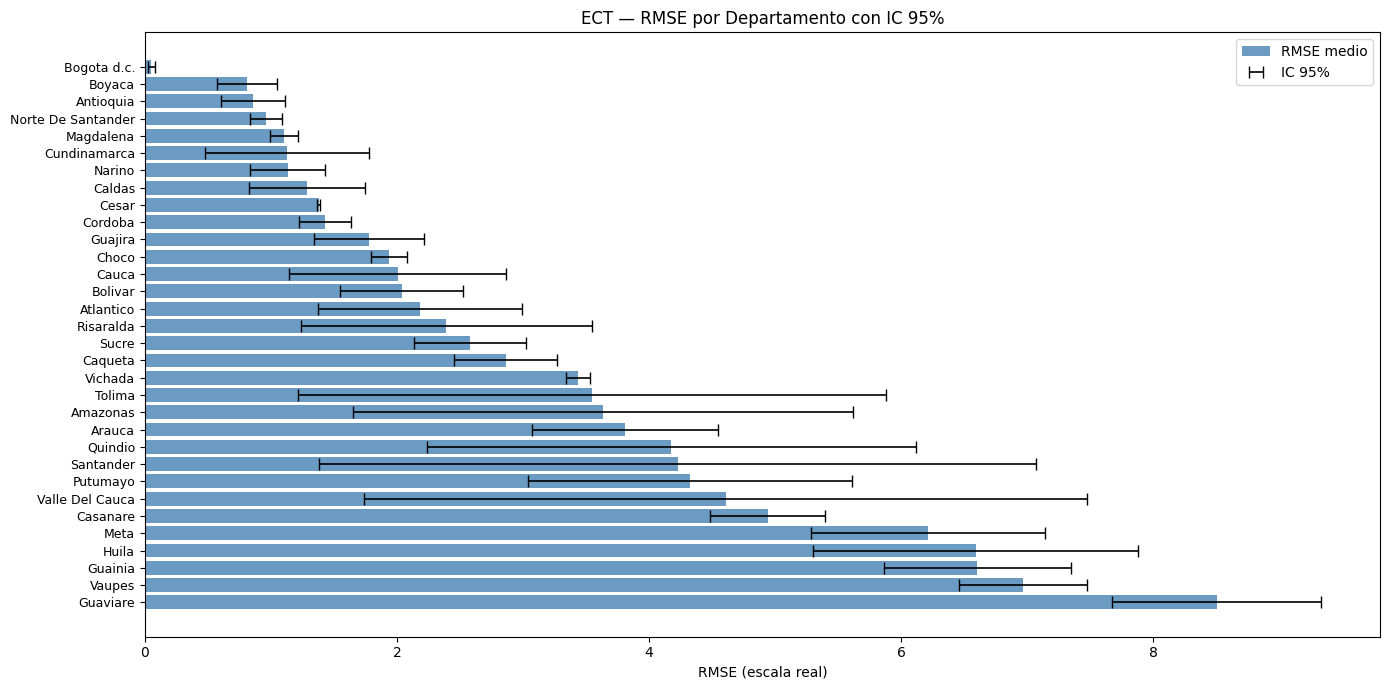

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

dm    = dept_metrics.sort_values("RMSE_mean", ascending=False)
y_pos = np.arange(len(dm))

ax.barh(y_pos, dm["RMSE_mean"], color="steelblue", alpha=0.8, label="RMSE medio")
ax.errorbar(
    dm["RMSE_mean"], y_pos,
    xerr=[
        dm["RMSE_mean"] - dm["RMSE_ci_lo"],
        dm["RMSE_ci_hi"] - dm["RMSE_mean"]
    ],
    fmt="none", color="black", capsize=4, linewidth=1.2,
    label="IC 95%"
)

ax.set_yticks(y_pos)
ax.set_yticklabels(dm["departamento"], fontsize=9)
ax.set_xlabel("RMSE (escala real)")
ax.set_title("ECT — RMSE por Departamento con IC 95%")
ax.legend()
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/ect_rmse_by_dept.png", dpi=150)
plt.show()

La distribución espacial de errores muestra un patrón claro y epidemiológicamente consistente. Los departamentos andinos y de baja carga (Bogotá, Boyacá, Antioquia, Norte de Santander) presentan los menores RMSE (<1.0) y alta estabilidad entre semillas, indicando predicciones robustas. En el rango intermedio (RMSE 1–3) se ubican departamentos del Caribe y Eje Cafetero como Magdalena, Córdoba, Caldas y Bolívar, donde el modelo captura la estacionalidad pero con mayor incertidumbre.

En contraste, los mayores errores se concentran en Orinoquía y Amazonía (Guaviare, Vaupés, Guainía, Meta, Casanare, Huila), con RMSE entre 5 y 9 e intervalos amplios, reflejando dinámicas hiperendémicas y brotes irregulares difíciles de modelar. Adicionalmente, departamentos como Tolima, Quindío, Santander y Valle del Cauca muestran intervalos de confianza amplios pese a errores medios moderados, lo que sugiere inestabilidad entre semillas y posibles problemas de consistencia predictiva.


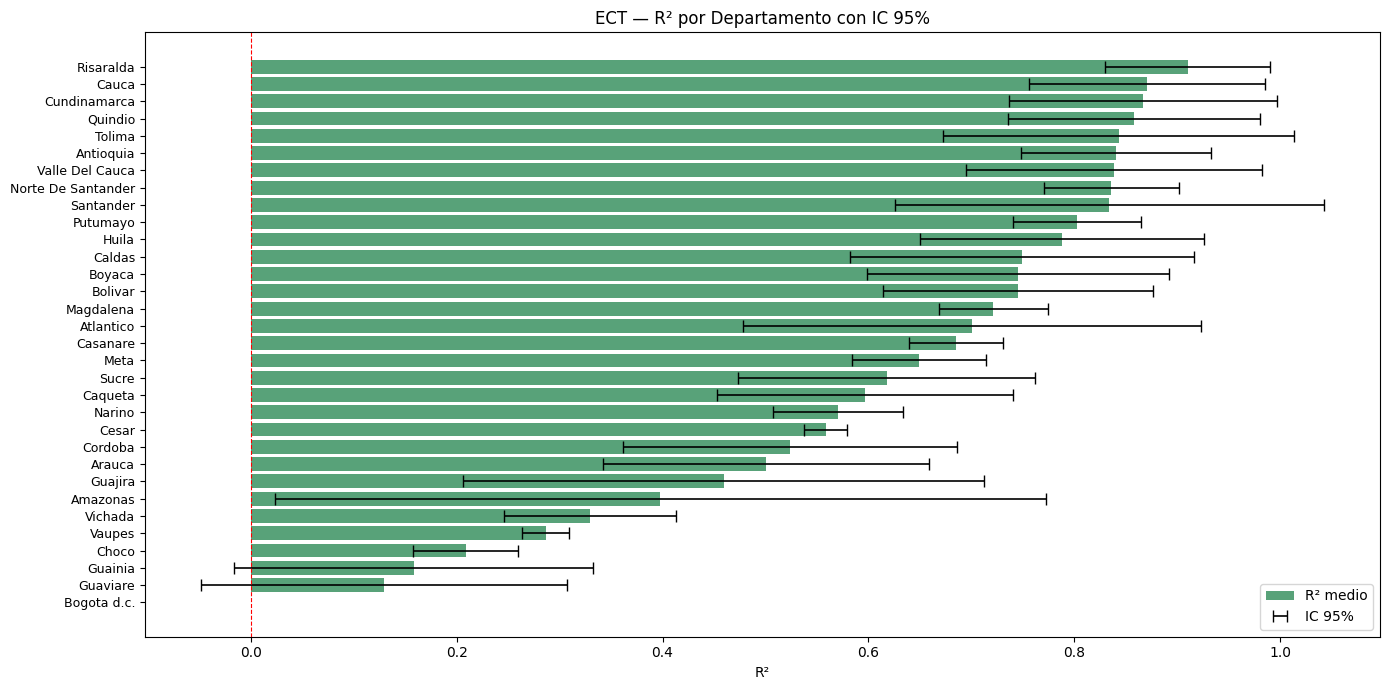

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

dm2   = dept_metrics.sort_values("R2_mean")
y_pos = np.arange(len(dm2))

ax.barh(y_pos, dm2["R2_mean"], color="seagreen", alpha=0.8, label="R² medio")
ax.errorbar(
    dm2["R2_mean"], y_pos,
    xerr=[
        dm2["R2_mean"] - dm2["R2_ci_lo"],
        dm2["R2_ci_hi"] - dm2["R2_mean"]
    ],
    fmt="none", color="black", capsize=4, linewidth=1.2,
    label="IC 95%"
)

ax.set_yticks(y_pos)
ax.set_yticklabels(dm2["departamento"], fontsize=9)
ax.axvline(x=0, color="red", linestyle="--", linewidth=0.8)
ax.set_xlabel("R²")
ax.set_title("ECT — R² por Departamento con IC 95%")
ax.legend()
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/ect_r2_by_dept.png", dpi=150)
plt.show()

El R² evidencia un fuerte gradiente geográfico en el desempeño del ECT. El mejor ajuste (R² > 0.85) se observa en departamentos andinos como Antioquia, Cundinamarca, Tolima, Quindío y Cauca, donde el modelo captura bien patrones estacionales. Un grupo intermedio (0.60–0.80) incluye regiones como Santander, Huila y Magdalena, con desempeño aceptable pero más variable.

En contraste, los peores resultados se concentran en la Amazonía y Orinoquía (Guaviare, Guainía, Vaupés, Vichada, Chocó), con R² entre 0.1 y 0.3 e incluso valores negativos en algunos casos, indicando bajo poder explicativo frente a la media. Bogotá presenta R² = 0 por varianza nula. En conjunto, el modelo es claramente más efectivo en regiones andinas y limita su generalización en zonas de dinámica epidemiológica irregular.


### **11.11.3. Predicciones por Departamento**

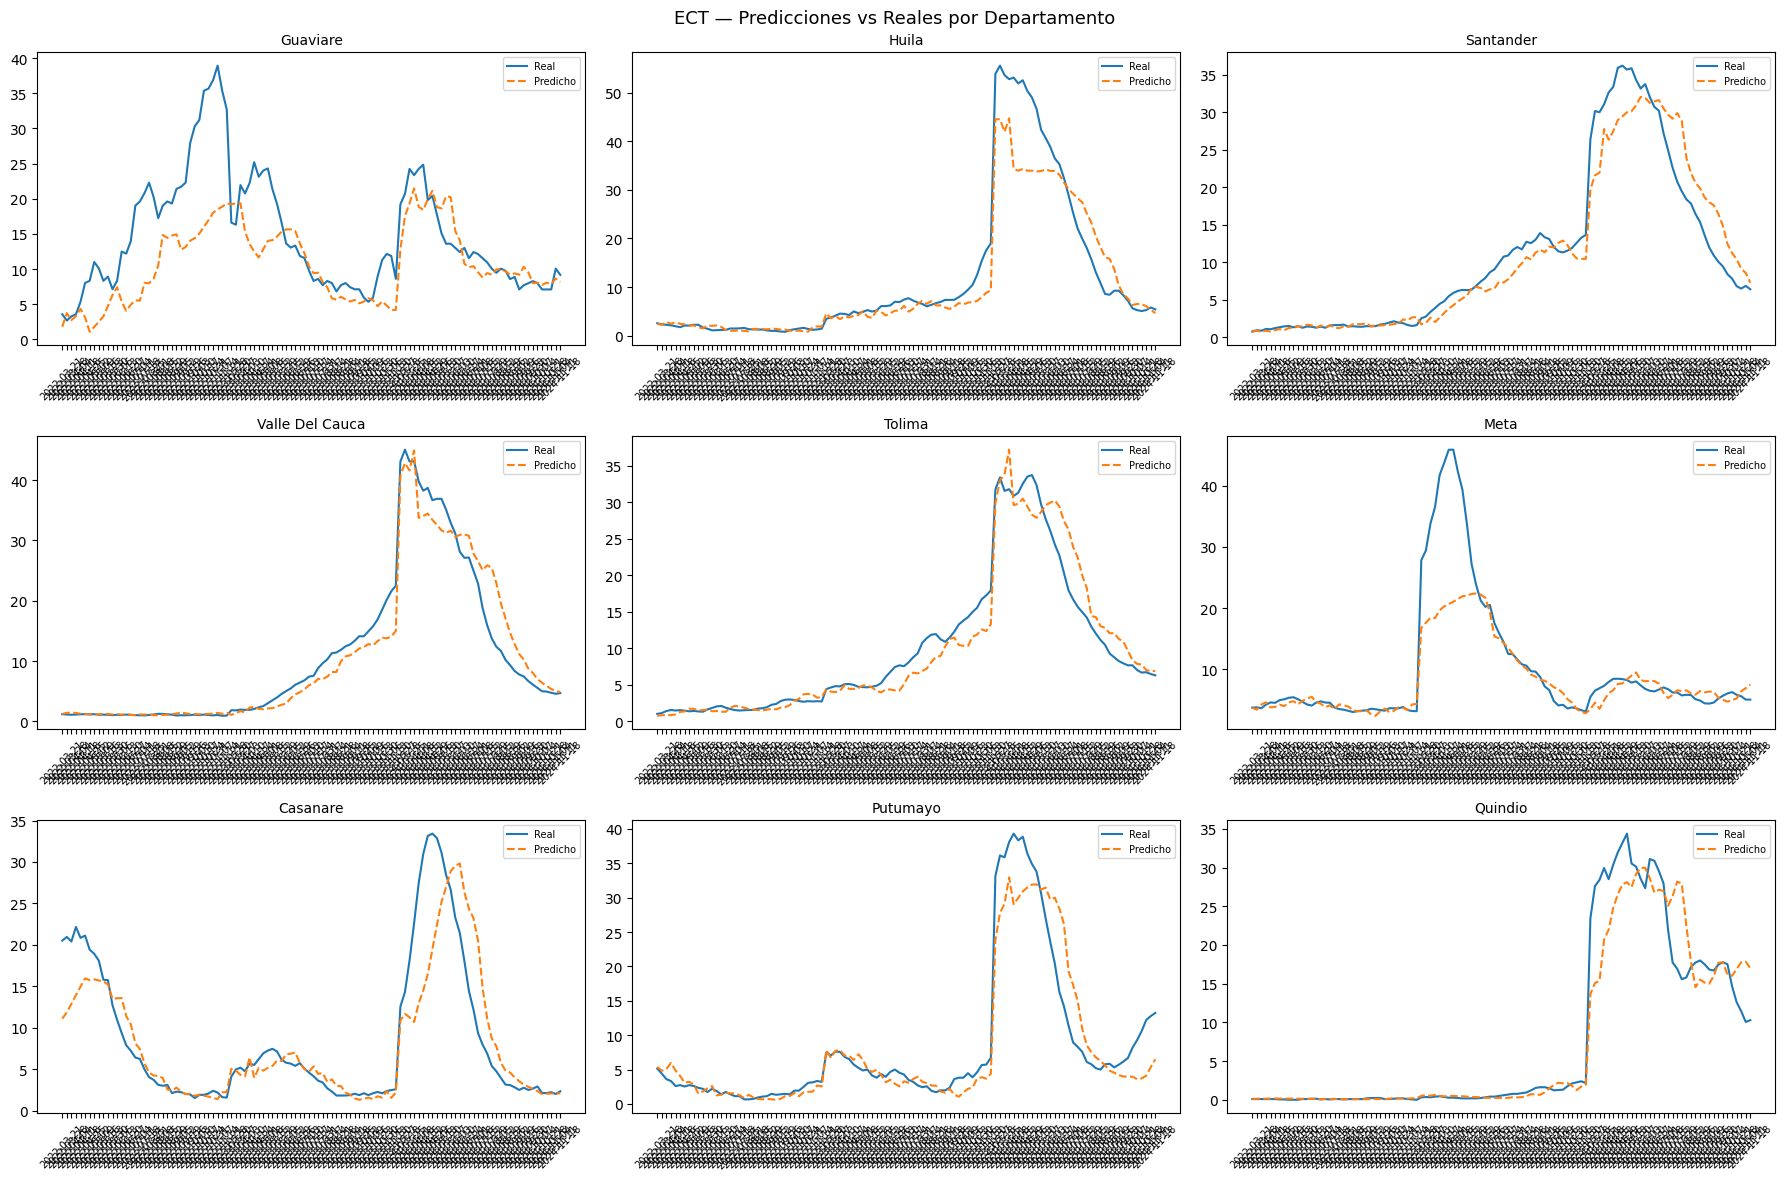

In [ ]:
top_depts = (
    preds.groupby("departamento")["y_true_real"]
    .mean()
    .sort_values(ascending=False)
    .head(9)
    .index.tolist()
)

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes      = axes.flatten()

for ax, dept in zip(axes, top_depts):
    sub = preds[preds["departamento"] == dept].sort_values("fecha_base")
    agg = sub.groupby("fecha_base")[["y_true_real","y_pred_real"]].mean()

    ax.plot(agg.index, agg["y_true_real"], label="Real",     linewidth=1.5)
    ax.plot(agg.index, agg["y_pred_real"], label="Predicho", linewidth=1.5, linestyle="--")
    ax.set_title(dept, fontsize=10)
    ax.legend(fontsize=7)
    ax.tick_params(axis="x", rotation=45, labelsize=7)

plt.suptitle("ECT — Predicciones vs Reales por Departamento", fontsize=13)
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/ect_predictions_by_dept.png", dpi=150)
plt.show()

El modelo ECT captura adecuadamente la dinámica general del dengue, reproduciendo tendencias, estacionalidad y la forma de los brotes en la mayoría de departamentos, especialmente en regiones como Tolima, Santander y Quindío. No obstante, su principal limitación es la subestimación sistemática de los picos epidémicos, donde suaviza los valores extremos y en algunos casos desacierta el momento del máximo, particularmente en departamentos como Huila, Meta, Casanare y Putumayo. En conjunto, el modelo es eficaz para seguir patrones temporales globales, pero menos preciso para representar la magnitud de eventos extremos críticos para la alerta epidemiológica.

### **11.11.4. Intervalos de Confianza Globales**

In [ ]:

def mean_ci(series, confidence=0.95):
    mean = np.mean(series)
    sem  = st.sem(series)
    ci   = st.t.interval(confidence, df=len(series)-1, loc=mean, scale=sem)
    return mean, ci


rmse_mean, rmse_ci = mean_ci(metrics_real["RMSE"])
mae_mean,  mae_ci  = mean_ci(metrics_real["MAE"])
r2_mean,   r2_ci   = mean_ci(metrics_real["R2"])

print(f"RMSE: {rmse_mean:.4f}  IC 95%: [{rmse_ci[0]:.4f}, {rmse_ci[1]:.4f}]")
print(f"MAE:  {mae_mean:.4f}  IC 95%: [{mae_ci[0]:.4f},  {mae_ci[1]:.4f}]")
print(f"R²:   {r2_mean:.4f}  IC 95%: [{r2_ci[0]:.4f},   {r2_ci[1]:.4f}]")

RMSE: 3.7674  IC 95%: [3.3163, 4.2185]
MAE:  1.9447  IC 95%: [1.7136,  2.1758]
R²:   0.7433  IC 95%: [0.7269,   0.7598]


Los intervalos de confianza confirman la robustez del ECT. El RMSE medio de 3.77 [3.32, 4.22] indica un error estable y acotado, con un máximo esperado inferior a ~4.2 casos por departamento-semana. El MAE de 1.94 [1.71, 2.18] sugiere errores promedio bajos y operativamente manejables para vigilancia epidemiológica. El R² de 0.743 [0.727, 0.760] es especialmente sólido, ya que incluso en el peor escenario el modelo explica más del 72% de la varianza. En conjunto, la estrechez de los intervalos evidencia alta estabilidad frente a cambios de semilla, lo que respalda su confiabilidad para uso en entornos de predicción en salud pública.

### **11.11.5. Análisis de Residuos**

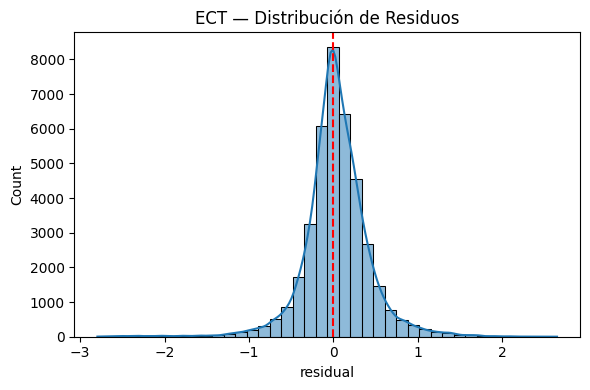

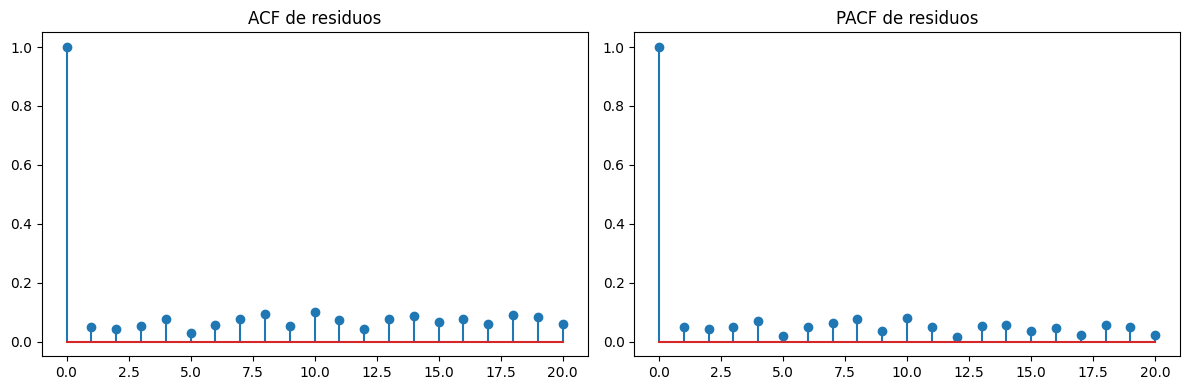

Test Ljung-Box:
        lb_stat  lb_pvalue
10  1729.444772        0.0
20  3825.224496        0.0


In [28]:
# Distribución de residuos
plt.figure(figsize=(6, 4))
sns.histplot(residuals["residual"], bins=40, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("ECT — Distribución de Residuos")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/ect_residuals_hist.png", dpi=150)
plt.show()

# ACF / PACF
acf_vals  = acf( residuals["residual"], nlags=20)
pacf_vals = pacf(residuals["residual"], nlags=20)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].stem(range(len(acf_vals)),  acf_vals)
axes[0].set_title("ACF de residuos")
axes[1].stem(range(len(pacf_vals)), pacf_vals)
axes[1].set_title("PACF de residuos")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/ect_residuals_acf.png", dpi=150)
plt.show()

lb = acorr_ljungbox(residuals["residual"], lags=[10, 20], return_df=True)
print("Test Ljung-Box:")
print(lb)

Los residuos están centrados en cero y muestran una forma aproximadamente normal, lo que indica ausencia de sesgo sistemático y errores mayoritariamente pequeños, consistentes con el MAE observado. Sin embargo, los diagnósticos de dependencia temporal revelan una limitación importante: existe autocorrelación significativa en los residuos, especialmente en el primer rezago, y el test de Ljung–Box rechaza la hipótesis de independencia (p≈0 en múltiples lags). Esto implica que el modelo no captura completamente la estructura temporal de la serie, dejando patrones residuales correlacionados. En conjunto, el ECT es estadísticamente bien calibrado en promedio, pero aún incompleto en su modelado de la dependencia temporal fina.


### **11.11.6. Curvas de Aprendizaje**

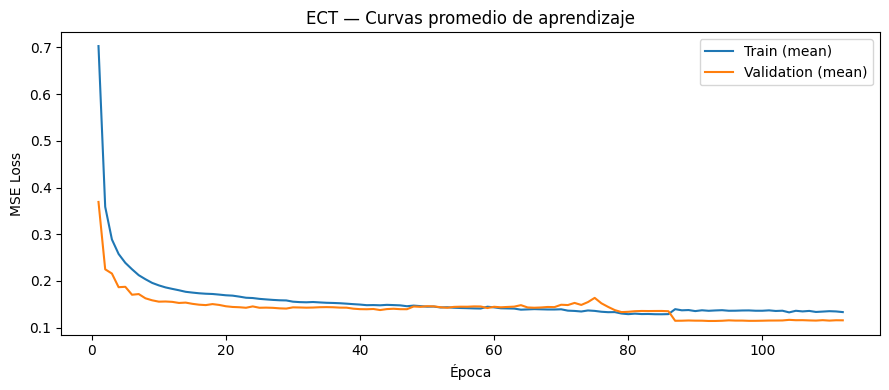

In [29]:
avg_history = history.groupby("epoch")[["train_loss","val_loss"]].mean().reset_index()

plt.figure(figsize=(9, 4))
plt.plot(avg_history["epoch"], avg_history["train_loss"], label="Train (mean)")
plt.plot(avg_history["epoch"], avg_history["val_loss"],   label="Validation (mean)")
plt.title("ECT — Curvas promedio de aprendizaje")
plt.xlabel("Época")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/ect_learning_curves.png", dpi=150)
plt.show()

Las curvas de aprendizaje muestran una convergencia estable, con una caída rápida inicial y estabilización alrededor de 0.10–0.12 sin oscilaciones ni divergencias entre entrenamiento y validación, lo que indica buena generalización y ausencia de overfitting. La brecha entre ambas curvas es mínima y constante, y se observa un plateau desde aproximadamente la época 80, sugiriendo que el modelo ya alcanzó su capacidad óptima y que el entrenamiento adicional no aporta mejoras. En conjunto, este comportamiento confirma una optimización adecuada, pero también respalda que las limitaciones detectadas en los residuos no se deben al entrenamiento sino a restricciones estructurales del modelo.

### **11.11.7. Casos de Mayor Error**

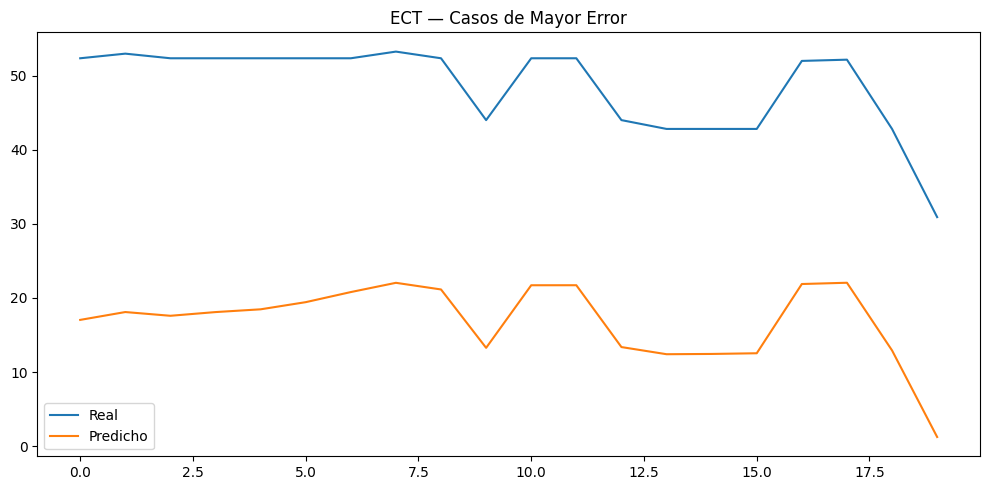

In [30]:
worst = preds.copy()
worst["error"] = (worst["y_true_real"] - worst["y_pred_real"]).abs()
worst_cases    = worst.sort_values("error", ascending=False).head(20)

plt.figure(figsize=(10, 5))
plt.plot(worst_cases["y_true_real"].values, label="Real")
plt.plot(worst_cases["y_pred_real"].values, label="Predicho")
plt.title("ECT — Casos de Mayor Error")
plt.legend()
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/ect_worst_cases.png", dpi=150)
plt.show()

La gráfica evidencia que en los departamentos de mayor incidencia, las predicciones subestiman de forma sistemática los valores reales en aproximadamente un 50–60%, manteniéndose una brecha constante a lo largo de todo el horizonte. Este comportamiento no se limita a picos puntuales, sino que refleja una incapacidad estructural del modelo para alcanzar niveles altos de incidencia, consistente con lo observado en los análisis por departamento y en la autocorrelación residual. La explicación más probable es un sesgo hacia la media inducido por el entrenamiento global, donde el modelo prioriza el ajuste promedio a costa de los extremos. Esto sugiere la necesidad de estrategias como pérdidas ponderadas, enfoques por cuantiles o calibración específica para regiones hiperendémicas.
